## В этом модуле, мы разберемся с задачей, начнем исследовать данные

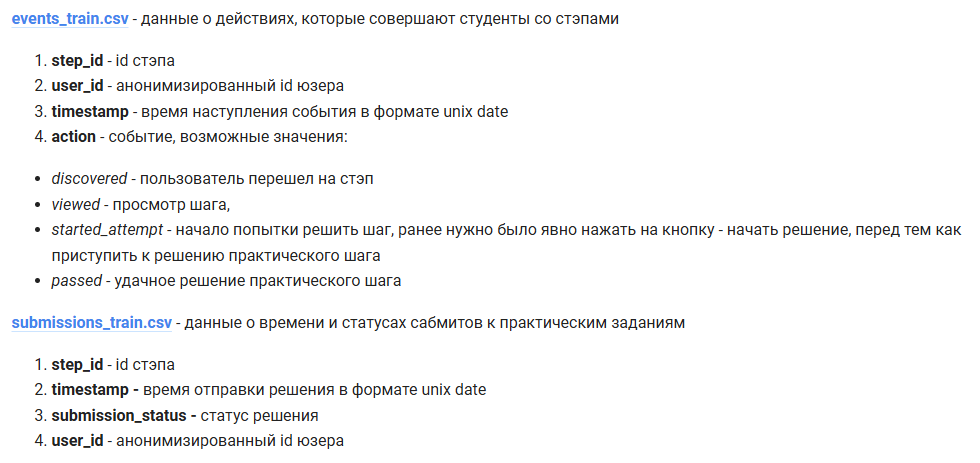

In [1]:
import pandas as pd
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
!wget https://stepik.org/media/attachments/course/4852/event_data_train.zip

--2026-04-27 09:45:06--  https://stepik.org/media/attachments/course/4852/event_data_train.zip
Resolving stepik.org (stepik.org)... 178.248.239.111
Connecting to stepik.org (stepik.org)|178.248.239.111|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 18905519 (18M) [application/zip]
Saving to: ‘event_data_train.zip’

event_data_train.zi  57%[==========>         ]  10.31M  16.7KB/s    in 77s     

2026-04-27 09:46:24 (137 KB/s) - Connection closed at byte 10813440. Retrying.

--2026-04-27 09:46:25--  (try: 2)  https://stepik.org/media/attachments/course/4852/event_data_train.zip
Connecting to stepik.org (stepik.org)|178.248.239.111|:443... connected.
HTTP request sent, awaiting response... 206 Partial Content
Length: 18905519 (18M), 8092079 (7.7M) remaining [application/zip]
Saving to: ‘event_data_train.zip’

event_data_train.zi 100%[+++++++++++========>]  18.03M  1.18MB/s    in 13s     

2026-04-27 09:46:39 (591 KB/s) - ‘event_data_train.zip’ saved [18905519/18

In [3]:
!unzip /content/event_data_train.zip -d data

Archive:  /content/event_data_train.zip
  inflating: data/event_data_train.csv  


In [4]:
events_data = pd.read_csv('/content/data/event_data_train.csv')
events_data.head()

,step_id,timestamp,action,user_id
0,32815,1434340848,viewed,17632
1,32815,1434340848,passed,17632
2,32815,1434340848,discovered,17632
3,32811,1434340895,discovered,17632
4,32811,1434340895,viewed,17632


In [5]:
events_data.action.unique()

array(['viewed', 'passed', 'discovered', 'started_attempt'], dtype=object)

'viewed' - посмотреть, 'passed' - решить, 'discovered' - впервые увидеть, 'started_attempt' - начать решать

In [6]:
events_data['date'] = pd.to_datetime(events_data.timestamp, unit = 's')
events_data.head()

,step_id,timestamp,action,user_id,date
0,32815,1434340848,viewed,17632,2015-06-15 04:00:48
1,32815,1434340848,passed,17632,2015-06-15 04:00:48
2,32815,1434340848,discovered,17632,2015-06-15 04:00:48
3,32811,1434340895,discovered,17632,2015-06-15 04:01:35
4,32811,1434340895,viewed,17632,2015-06-15 04:01:35


In [7]:
events_data.dtypes

,0
step_id,int64
timestamp,int64
action,object
user_id,int64
date,datetime64[ns]


In [8]:
events_data.date.min()

Timestamp('2015-06-15 04:00:48')

In [9]:
events_data.date.max()

Timestamp('2018-05-19 23:33:31')

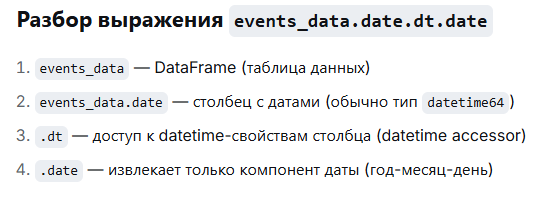

In [10]:
events_data['day'] = events_data.date.dt.date
events_data.head()

,step_id,timestamp,action,user_id,date,day
0,32815,1434340848,viewed,17632,2015-06-15 04:00:48,2015-06-15
1,32815,1434340848,passed,17632,2015-06-15 04:00:48,2015-06-15
2,32815,1434340848,discovered,17632,2015-06-15 04:00:48,2015-06-15
3,32811,1434340895,discovered,17632,2015-06-15 04:01:35,2015-06-15
4,32811,1434340895,viewed,17632,2015-06-15 04:01:35,2015-06-15


##### Сколько человек и в какой день записалось

In [16]:
events_data.groupby('day', as_index=False) \
           .user_id.nunique() \
           .head()

,day,user_id
0,2015-06-15,705
1,2015-06-16,526
2,2015-06-17,440
3,2015-06-18,411
4,2015-06-19,377


<Axes: xlabel='day'>

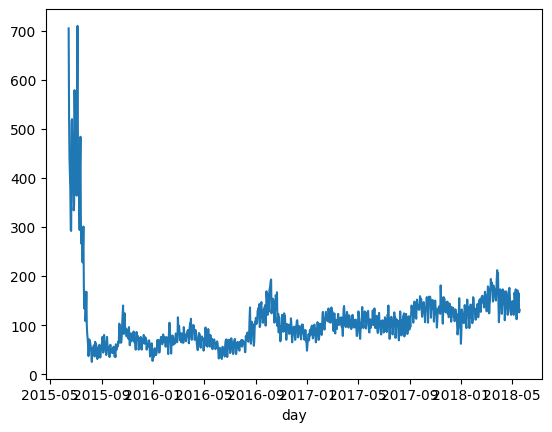

In [15]:
events_data.groupby('day') \
           .user_id.nunique() \
           .plot()

In [ ]:
# Надстройка для изменения размера графика
sns.set(rc={'figure.figsize': (9,6)})

<Axes: xlabel='day'>

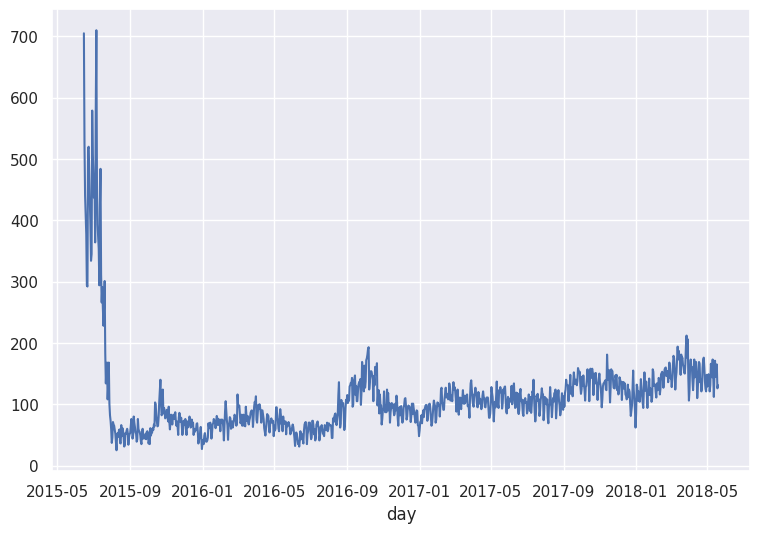

In [ ]:
events_data.groupby('day') \
.user_id.nunique().plot()

#### Распределение пользователей по количеству баллов

<Axes: >

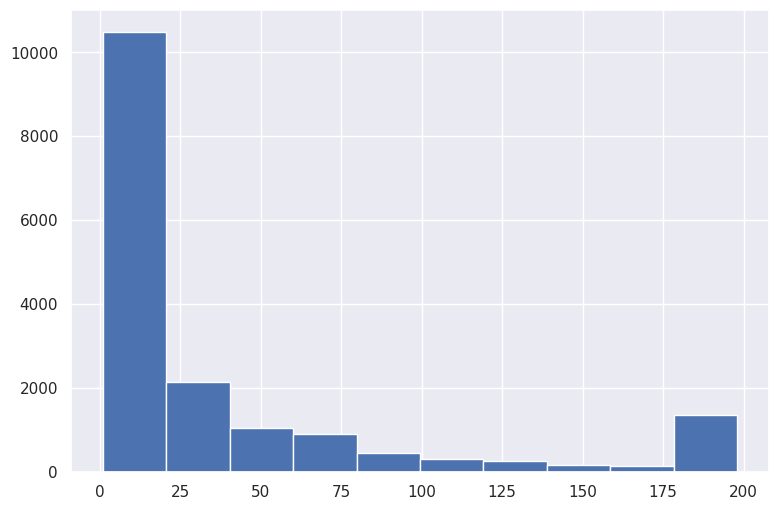

In [ ]:
events_data[events_data.action == 'passed'] \
    .groupby('user_id', as_index = False) \
    .agg({'step_id': 'count'}) \
    .rename(columns = {'step_id': 'passed_step'}).passed_step.hist()

In [ ]:
events_data[events_data.action == 'passed'] \
    .groupby('user_id', as_index = False) \
    .agg({'step_id': 'count'}) \
    .rename(columns = {'step_id': 'passed_step'}).passed_step.min()

1

In [ ]:
# включаем 0 в выборку
events_data.pivot_table(index='user_id',
                        columns='action',
                        values='step_id',
                        aggfunc='count',
                        fill_value=0).reset_index().head()

action,user_id,discovered,passed,started_attempt,viewed
0,1,1,0,0,1
1,2,9,9,2,10
2,3,91,87,30,192
3,5,11,11,4,12
4,7,1,1,0,1


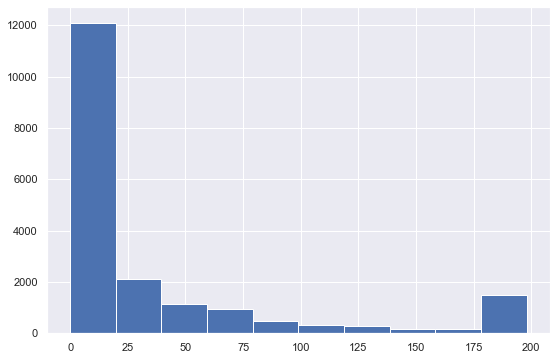

In [ ]:
events_data.pivot_table(index='user_id',
                        columns='action',
                        values='step_id',
                        aggfunc='count',
                        fill_value=0).reset_index().discovered.hist()